# Lab: Química con Python -- la tabla periódica como datos

**Meta:** trabajar con la **química** usando su librería de dominio, **mendeleev**: pedirle la **tabla periódica como datos** (`fetch_table`) y recibir un **DataFrame** (el de la L21). Como es un DataFrame, podrás **buscar** un elemento, **filtrar** subconjuntos y **graficar una tendencia periódica** (radio atómico contra número atómico), todo con lo que ya sabes de Pandas (L21-L22) y de visualización (L23). Al final, una **demo** de **RDKit** (no examinable): de un texto `SMILES` a la fórmula, la masa molecular y la estructura de una molécula. Acompaña a la nota de concepto [Química con Python](l26_concept_chemistry_mendeleev.qmd).

> **Cómo usar este lab:** ejecuta cada celda con `Shift + Enter`, empezando por las dos celdas de preparación. Donde diga **Tu turno**, hay un bloque comentado con una parte marcada con `____` que debes **completar** al quitar los `#`. Compara con la respuesta esperada del bloque desplegable.

## Preparación

Necesitamos **mendeleev** (la tabla periódica como datos) y **RDKit** (estructuras moleculares, para la demo final). Corre estas **dos** celdas primero. La primera las instala (en Colab; si ya están, no hace nada). La segunda importa lo que usaremos: `fetch_table` para traer la tabla, `plt` para graficar, y de RDKit `Chem`/`Descriptors`/`rdMolDescriptors`/`Draw` para la demo.

In [1]:
%pip install -q mendeleev rdkit

Note: you may need to restart the kernel to use updated packages.


In [2]:
from mendeleev.fetch import fetch_table
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw

print("mendeleev y RDKit listos para trabajar")

mendeleev y RDKit listos para trabajar


~~~text
mendeleev y RDKit listos para trabajar
~~~

## Paso 1: la tabla periódica como un DataFrame

mendeleev trae la tabla periódica **empaquetada** (sin descargas). `fetch_table('elements')` la entrega como un **DataFrame** de Pandas: una fila por elemento, una columna por propiedad.

In [3]:
tabla = fetch_table('elements')
print("numero de elementos:", len(tabla))

numero de elementos: 118


~~~text
numero de elementos: 118
~~~

Son **118 elementos** (las filas), cada uno con **decenas de propiedades** (las columnas): demasiadas para mirarlas todas. Nos quedamos con unas pocas columnas útiles (seleccionar varias columnas con una lista, como en la L21) y vemos las primeras filas con `.head()`:

In [4]:
elementos = tabla[['atomic_number', 'symbol', 'name', 'atomic_weight', 'en_pauling', 'atomic_radius']]
print(elementos.head())

   atomic_number symbol       name  atomic_weight  en_pauling  atomic_radius
0              1      H   Hydrogen       1.008000        2.20           25.0
1              2     He     Helium       4.002602         NaN          120.0
2              3     Li    Lithium       6.940000        0.98          145.0
3              4     Be  Beryllium       9.012183        1.57          105.0
4              5      B      Boron      10.810000        2.04           85.0


~~~text
   atomic_number symbol       name  atomic_weight  en_pauling  atomic_radius
0              1      H   Hydrogen       1.008000        2.20           25.0
1              2     He     Helium       4.002602         NaN          120.0
2              3     Li    Lithium       6.940000        0.98          145.0
3              4     Be  Beryllium       9.012183        1.57          105.0
4              5      B      Boron      10.810000        2.04           85.0
~~~

Cada columna es una propiedad: `atomic_number` (el número atómico Z), `symbol`, `name`, `atomic_weight` (masa atómica en u), `en_pauling` (la electronegatividad de Pauling) y `atomic_radius` (el radio atómico en pm). El `NaN` del helio significa "sin valor": los gases nobles casi no forman enlaces, así que no tienen electronegatividad definida.

## Paso 2: buscar un elemento

Para buscar un elemento, **filtramos** las filas por una columna, igual que en la L21 (`df[df['col'] == valor]`). Busquemos el hierro por su símbolo:

In [5]:
hierro = elementos[elementos['symbol'] == 'Fe']
print(hierro)

    atomic_number symbol  name  atomic_weight  en_pauling  atomic_radius
25             26     Fe  Iron         55.845        1.83          140.0


~~~text
    atomic_number symbol  name  atomic_weight  en_pauling  atomic_radius
25             26     Fe  Iron         55.845        1.83          140.0
~~~

El hierro es el elemento **26**, pesa **55.845 u**, tiene electronegatividad **1.83** y radio **140 pm**. El `25` de la izquierda es el índice de la fila (el hierro es la fila 25, contando desde 0).

## Paso 3: subconjuntos de la tabla

Un **filtro** sobre una columna te da un **subconjunto** de elementos. Dos ejemplos.

**Una fila de la tabla periódica (un periodo).** La columna `period` (el periodo) es una de las muchas columnas de la tabla completa, aunque no la guardamos en `elementos`. Filtramos sobre `tabla` y mostramos unas columnas:

In [6]:
print(tabla[tabla['period'] == 2][['atomic_number', 'symbol', 'name', 'atomic_radius']])

   atomic_number symbol       name  atomic_radius
2              3     Li    Lithium          145.0
3              4     Be  Beryllium          105.0
4              5      B      Boron           85.0
5              6      C     Carbon           70.0
6              7      N   Nitrogen           65.0
7              8      O     Oxygen           60.0
8              9      F   Fluorine           50.0
9             10     Ne       Neon          160.0


~~~text
   atomic_number symbol       name  atomic_radius
2              3     Li    Lithium          145.0
3              4     Be  Beryllium          105.0
4              5      B      Boron           85.0
5              6      C     Carbon           70.0
6              7      N   Nitrogen           65.0
7              8      O     Oxygen           60.0
8              9      F   Fluorine           50.0
9             10     Ne       Neon          160.0
~~~

Es el **periodo 2** (la segunda fila de la tabla periódica), de litio a neón. Fíjate en el radio: **baja** de Li (145) a F (50) al avanzar en el periodo (el neón, un gas noble, se mide de otra forma y se sale: 160). Lo veremos graficado en el Paso 4.

**Los más electronegativos.** Filtramos por una propiedad continua: los elementos con electronegatividad mayor que 3.0.

In [7]:
print(elementos[elementos['en_pauling'] > 3.0])

    atomic_number symbol      name  atomic_weight  en_pauling  atomic_radius
6               7      N  Nitrogen      14.007000        3.04           65.0
7               8      O    Oxygen      15.999000        3.44           60.0
8               9      F  Fluorine      18.998403        3.98           50.0
16             17     Cl  Chlorine      35.450000        3.16          100.0


~~~text
    atomic_number symbol      name  atomic_weight  en_pauling  atomic_radius
6               7      N  Nitrogen      14.007000        3.04           65.0
7               8      O    Oxygen      15.999000        3.44           60.0
8               9      F  Fluorine      18.998403        3.98           50.0
16             17     Cl  Chlorine      35.450000        3.16          100.0
~~~

Solo cuatro: nitrógeno, oxígeno, flúor y cloro. El **flúor** (3.98) es el elemento más electronegativo de todos. Es el mismo filtro booleano de la L21, ahora respondiendo una pregunta de química.

## Paso 4: una tendencia periódica

Aquí se junta todo: una vez que la tabla es un DataFrame, **graficamos** una tendencia con `df.plot` (L23). Tomamos los primeros 20 elementos y graficamos su **radio atómico** contra su **número atómico**:

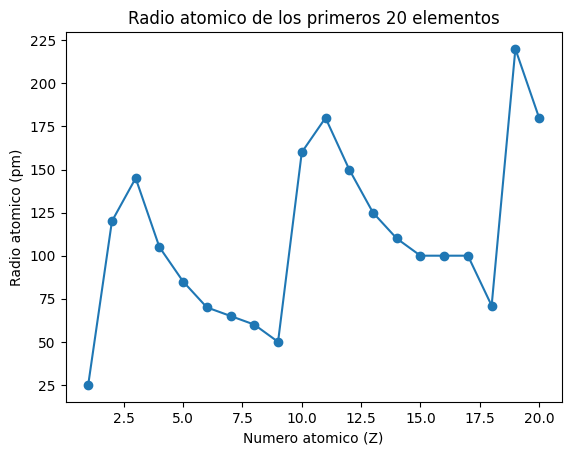

In [8]:
primeros = elementos[elementos['atomic_number'] <= 20]
primeros.plot(x='atomic_number', y='atomic_radius',
              title='Radio atomico de los primeros 20 elementos',
              xlabel='Numero atomico (Z)', ylabel='Radio atomico (pm)',
              marker='o', legend=False)
plt.show()

*(Al ejecutar se abre la figura: una curva en **diente de sierra**. El radio baja al avanzar dentro de un periodo (de Li en Z=3 hasta F en Z=9) y vuelve a subir al empezar el siguiente periodo, en los **metales alcalinos** (Na en Z=11, K en Z=19), que crecen al bajar por el grupo: Li (145) < Na (180) < K (220). El patrón se **repite** cada periodo: por eso la tabla es "periódica". Ojo con los **gases nobles** (He, Ne, Ar): se miden de otra forma y quedan fuera del patrón; el Ne en Z=10 aparece incluso por encima del Li.)*

Una gráfica científica siempre lleva **título** y **rótulos de eje con unidades** (aquí el radio en `pm`, picómetros), como aprendiste en la L23.

## Tu turno (programa completo)

### Ejercicio: las propiedades de un elemento

Busca el **oxígeno** (símbolo `O`) en la tabla y muestra sus propiedades, igual que hicimos con el hierro en el Paso 2. Completa la parte que falta.

In [9]:
# TODO: quita los # y completa el ____ con el simbolo del oxigeno.
# oxigeno = elementos[elementos['symbol'] == ____]
# print(oxigeno)

<details><summary>Respuesta esperada</summary>

La parte que falta es el símbolo entre comillas, `'O'`:

~~~python
oxigeno = elementos[elementos['symbol'] == 'O']
print(oxigeno)
~~~

Al ejecutarlo imprime:

~~~text
   atomic_number symbol    name  atomic_weight  en_pauling  atomic_radius
7              8      O  Oxygen         15.999        3.44           60.0
~~~

El oxígeno es el elemento **8**, pesa **15.999 u**, tiene electronegatividad **3.44** (alta: por eso salió en el filtro del Paso 3) y radio **60 pm**.
</details>

## Demo opcional (no examinable): de un SMILES a una molécula (RDKit)

mendeleev te da los **elementos**; **RDKit** te da las **moléculas**. Un `SMILES` es un texto que describe una molécula (`'CCO'` es el etanol). RDKit lo convierte en una molécula y calcula su **fórmula** y su **masa molecular**. Esto es una **demo** del instructor: no entra en el examen.

In [10]:
for nombre, smiles in [("agua", "O"), ("etanol", "CCO"), ("cafeina", "CN1C=NC2=C1C(=O)N(C(=O)N2C)C")]:
    molecula = Chem.MolFromSmiles(smiles)
    print(nombre, "->", rdMolDescriptors.CalcMolFormula(molecula),
          "| masa molecular:", round(Descriptors.MolWt(molecula), 2))

agua -> H2O | masa molecular: 18.02
etanol -> C2H6O | masa molecular: 46.07
cafeina -> C8H10N4O2 | masa molecular: 194.19


~~~text
agua -> H2O | masa molecular: 18.02
etanol -> C2H6O | masa molecular: 46.07
cafeina -> C8H10N4O2 | masa molecular: 194.19
~~~

Y RDKit también **dibuja** la estructura. Veamos la cafeína:

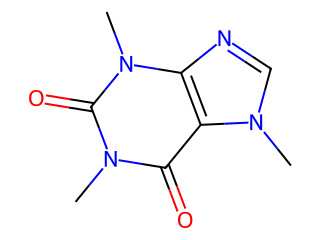

In [11]:
cafeina = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')
Draw.MolToImage(cafeina, size=(320, 240))

*(Al ejecutar se dibuja la estructura de la cafeína: dos anillos unidos con sus átomos de nitrógeno (en azul) y de oxígeno (en rojo). De un texto SMILES a la estructura química, en una línea.)*

## Resumen

- **mendeleev** es la librería de dominio de la **química**: `fetch_table('elements')` trae la **tabla periódica como un DataFrame** (118 elementos, una fila cada uno; columnas = propiedades).
- Como es un **DataFrame** (L21), aplica todo lo de Pandas: **seleccionar** columnas (`tabla[[...]]`), **buscar** un elemento (`elementos[elementos['symbol'] == 'Fe']`) y **filtrar** subconjuntos (`elementos[elementos['en_pauling'] > 3.0]`).
- **Propiedades y unidades:** `atomic_number` (Z), `atomic_weight` (u), `period`/`group_id` (las coordenadas de la tabla), `en_pauling` (electronegatividad) y `atomic_radius` (pm); `NaN` cuando no hay valor.
- **Tendencia periódica:** graficar `atomic_radius` contra `atomic_number` (L23) muestra el diente de sierra que se repite cada periodo -- por eso la tabla es "periódica".
- **Demo (no examinable):** **RDKit** convierte un `SMILES` en una molécula -> fórmula, masa molecular y estructura.
- **Sigue en la S27:** el proyecto del módulo, con una **pista de química** que usa exactamente estas herramientas.